# 5. Research question: Do small and large firms respond differently to trade shocks within the same industry?
   Estimating econometric model
   $y_{it} = β_{1}*Shock_{it} + β{2}*(Shock_{it} × Small_{f}) + Γ'X_{it} + μ_{f} + λ_{t} + \gamma_{i}+ ε_{it}$

$y_{it}$ = Year over year revenue Growth
Shock in industry i at time t is calculated using two methods - 
1. Changes in trade exposure = Percentage change in total trade as % of GDP
2. Change in import penetration = Percentage change in import as % of GDP
Small_f = Indicators of industry of firms with 20K-5M in revenue
4. Industry Effect
5. Time Effect
6. X_{it}=dummies for status

Standard errors are clustered to correct for correlation within the industries. 

Data Constraints: The large firms data are not available by province. It is avaialble by industry and time for the whole of Canada. As a results, the small firms dataset is restricted to whole of Canada. Trade data are aggregated for whole of Canada by industry codes and time.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
from sympy import symbols, Eq


# Data Cleaning

In [5]:
# Opening the reveue files of industries
df1 = pd.read_csv("Revenue_small.csv")
df1 = df1[df1['Province'] == 0] # Data not available for large firms
df1['small']=1 # small firm identifier
df1.head()

,Year,Naics code,Description_English,Province,Province_Description,Incorporation Status,Bottom quartile All other revenue,Bottom quartile High revenue range,Bottom quartile Low revenue range,Bottom quartile Sales of goods and services,...,Upper middle High revenue range,Upper middle Low revenue range,Upper middle Sales of goods and services,Upper middle Total revenue,Whole industry All other revenue,Whole industry High revenue range,Whole industry Sales of goods and services,Whole industry Total revenue,Whole industry low revenue range,small
0,2013,11,"Agriculture, Forestry, Fishing and Hunting",0,Canada Total,1,NaN,43,30,NaN,...,106,65,NaN,82.7,NaN,5000,NaN,101.1,30,1
1,2013,11,"Agriculture, Forestry, Fishing and Hunting",0,Canada Total,1,20.3,162,30,65.3,...,954,432,598.0,653.5,61.9,5000,669.9,731.8,30,1
2,2013,11,"Agriculture, Forestry, Fishing and Hunting",0,Canada Total,1,NaN,78,30,NaN,...,705,238,NaN,437.1,NaN,5000,NaN,560.1,30,1
51,2013,21,"Mining, Quarrying, and Oil and Gas Extraction",0,Canada Total,1,NaN,50,30,NaN,...,143,86,NaN,113.2,NaN,5000,NaN,122.5,30,1
52,2013,21,"Mining, Quarrying, and Oil and Gas Extraction",0,Canada Total,1,15.0,123,30,59.2,...,419,209,266.4,290.2,51.6,5000,453.5,505.0,30,1


In [6]:
df2 = pd.read_csv("Revenue_large.csv")
df2['small']=0
df2.head()

,Year,Naics code,Description_English,Province,Province_Description,Incorporation Status,Bottom quartile All other revenue,Bottom quartile High revenue range,Bottom quartile Low revenue range,Bottom quartile Sales of goods and services,...,Upper middle High revenue range,Upper middle Low revenue range,Upper middle Sales of goods and services,Upper middle Total revenue,Whole industry All other revenue,Whole industry High revenue range,Whole industry Sales of goods and services,Whole industry Total revenue,Whole industry low revenue range,small
0,2013,11,"Agriculture, Forestry, Fishing and Hunting",0.0,Canada Total,2,345.8,5953.0,5000.0,5109.1,...,10000.0,7403.0,8133.3,8699.0,561.4,20000.0,8077.7,8639.1,5000.0,0
1,2013,21,"Mining, Quarrying, and Oil and Gas Extraction",0.0,Canada Total,2,279.2,6484.0,5000.0,5460.5,...,12000.0,8433.0,9323.6,10088.3,730.0,20000.0,8946.9,9676.9,5000.0,0
2,2013,22,Utilities,0.0,Canada Total,2,817.3,6267.0,5000.0,4930.8,...,13000.0,9576.0,10381.1,11316.8,1119.0,20000.0,9115.4,10234.5,5000.0,0
3,2013,23,Construction,0.0,Canada Total,2,147.5,6187.0,5000.0,5414.9,...,12000.0,8135.0,9474.5,9725.4,209.8,20000.0,9154.4,9364.2,5000.0,0
4,2013,41,Wholesale Trade,0.0,Canada Total,2,91.5,6422.0,5000.0,5562.7,...,12000.0,8628.0,10204.8,10347.8,139.6,20000.0,9660.0,9799.6,5000.0,0


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61376 entries, 0 to 782497
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Year                                                61376 non-null  int64  
 1   Naics code                                          61376 non-null  int64  
 2   Description_English                                 61376 non-null  object 
 3   Province                                            61376 non-null  int64  
 4   Province_Description                                61376 non-null  object 
 5   Incorporation Status                                61376 non-null  int64  
 6   Bottom quartile All other revenue                   20738 non-null  float64
 7   Bottom quartile High revenue range                  61376 non-null  int64  
 8   Bottom quartile Low revenue range                   61376 non-null  int64  
 9  

In [8]:
df1['Year'].nunique()

11

In [9]:
df1['Naics code'].nunique()

2106

In [10]:
df1['Incorporation Status'].nunique()

1

In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11361 entries, 0 to 11360
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Year                                                11361 non-null  int64  
 1   Naics code                                          11361 non-null  int64  
 2   Description_English                                 11361 non-null  object 
 3   Province                                            11361 non-null  float64
 4   Province_Description                                11361 non-null  object 
 5   Incorporation Status                                11361 non-null  int64  
 6   Bottom quartile All other revenue                   11361 non-null  float64
 7   Bottom quartile High revenue range                  11361 non-null  float64
 8   Bottom quartile Low revenue range                   11361 non-null  float64


In [12]:
df2['Naics code'].nunique()

1154

In [13]:
df2['Year'].nunique()

11

In [14]:
df2['Incorporation Status'].nunique()

1

In [15]:
df=pd.concat([df1, df2],ignore_index=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72737 entries, 0 to 72736
Data columns (total 34 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Year                                                72737 non-null  int64  
 1   Naics code                                          72737 non-null  int64  
 2   Description_English                                 72737 non-null  object 
 3   Province                                            72737 non-null  float64
 4   Province_Description                                72737 non-null  object 
 5   Incorporation Status                                72737 non-null  int64  
 6   Bottom quartile All other revenue                   32099 non-null  float64
 7   Bottom quartile High revenue range                  72737 non-null  float64
 8   Bottom quartile Low revenue range                   72737 non-null  float64


In [17]:
df = df.rename(columns={"Whole industry Total revenue": "revenue"})
df= df[["Year", "Naics code", "small", "revenue"]] # Financial Data
df = df.rename(columns={"Naics code": "NAICS"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72737 entries, 0 to 72736
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     72737 non-null  int64  
 1   NAICS    72737 non-null  int64  
 2   small    72737 non-null  int64  
 3   revenue  72737 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 2.2 MB


In [18]:
df["industry"] = df["NAICS"].astype(str).str[:2].astype(int)

In [19]:
#Collapsing trade data by industry and year
trade = pd.read_csv("trade.csv")
trade = trade.rename(columns={"REF_DATE": "Year"})
#Collapsing trade data by industry and year
collapsedt = (
    trade.groupby(["industry", "Year"], as_index=False)
      .agg({
          "Value of exports": "sum",
          "Value of imports": "sum",
          "GDP": "sum"
      })
)
trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 10 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Province                                                 2029 non-null   object 
 1   industry                                                 2029 non-null   int64  
 2   Year                                                     2029 non-null   int64  
 3   North American Industry Classification System (NAICS)_y  2029 non-null   object 
 4   total_trade                                              2029 non-null   float64
 5   Value of exports                                         2029 non-null   float64
 6   Value of imports                                         2029 non-null   float64
 7   GDP                                                      2029 non-null   int64  
 8   trade_pct_gdp               

In [20]:
collapsedt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   industry          231 non-null    int64  
 1   Year              231 non-null    int64  
 2   Value of exports  231 non-null    float64
 3   Value of imports  231 non-null    float64
 4   GDP               231 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 9.2 KB


In [21]:
unique_list = collapsedt["industry"].unique().tolist()
print(unique_list)

[0, 11, 21, 22, 23, 31, 41, 44, 48, 51, 52, 53, 54, 55, 56, 61, 62, 71, 72, 81, 91]


In [22]:
unique_list = df["industry"].unique().tolist()
print(unique_list)

[11, 21, 22, 23, 41, 51, 53, 54, 55, 56, 61, 62, 71, 72, 81, 31, 32, 33, 44, 45, 48, 49, 0]


Note: The industry is not the same for both.

In [24]:
# Merging financial data with trade data
data = pd.merge(df, collapsedt, on=["industry", "Year"],   how="left")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72737 entries, 0 to 72736
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              72737 non-null  int64  
 1   NAICS             72737 non-null  int64  
 2   small             72737 non-null  int64  
 3   revenue           72737 non-null  float64
 4   industry          72737 non-null  int32  
 5   Value of exports  53893 non-null  float64
 6   Value of imports  53893 non-null  float64
 7   GDP               53893 non-null  float64
dtypes: float64(4), int32(1), int64(3)
memory usage: 4.2 MB


In [25]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53893 entries, 0 to 72736
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              53893 non-null  int64  
 1   NAICS             53893 non-null  int64  
 2   small             53893 non-null  int64  
 3   revenue           53893 non-null  float64
 4   industry          53893 non-null  int32  
 5   Value of exports  53893 non-null  float64
 6   Value of imports  53893 non-null  float64
 7   GDP               53893 non-null  float64
dtypes: float64(4), int32(1), int64(3)
memory usage: 3.5 MB


## Calculating Trade Exposure in 2 ways

In [27]:
# Total Trade Exposure
data['total_trade'] = data['Value of exports'] + data['Value of imports']
data["trade_pct_gdp"] = (data["total_trade"] / data["GDP"]) *(1/10)

data= data.set_index(["NAICS", "small","Year"]) # Setting data as panel

# lagged trade exposure
data["lag_trade_pct_gdp"] = data.groupby(["NAICS", "small"])["trade_pct_gdp"].shift(1)

# Calculate shock = Percentage change in total trade exposure
data["shock"] = (data["trade_pct_gdp"] - data["lag_trade_pct_gdp"]) *100 / data["lag_trade_pct_gdp"]


In [28]:
# Import Penetration
data["penetration"] = (data['Value of imports']/data["GDP"])*(1/10)
# lagged  penetration
data["lag_p"] = data.groupby(["NAICS", "small"])["penetration"].shift(1)

# Calculate shock = Percentage change in import penetration
data["shock2"] = (data["penetration"] - data["lag_p"]) *100 / data["penetration"]


## Calculating Revenue Growth

In [30]:
# Calculate previous revenue within each industry × firm_size group
data["prev_revenue"] = data.groupby(["NAICS", "small"])["revenue"].shift(1)

# Calculate growth
data["growth"] = (data["revenue"] - data["prev_revenue"]) *100 / data["prev_revenue"]
data = data.reset_index()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53893 entries, 0 to 53892
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NAICS              53893 non-null  int64  
 1   small              53893 non-null  int64  
 2   Year               53893 non-null  int64  
 3   revenue            53893 non-null  float64
 4   industry           53893 non-null  int32  
 5   Value of exports   53893 non-null  float64
 6   Value of imports   53893 non-null  float64
 7   GDP                53893 non-null  float64
 8   total_trade        53893 non-null  float64
 9   trade_pct_gdp      53893 non-null  float64
 10  lag_trade_pct_gdp  51514 non-null  float64
 11  shock              51514 non-null  float64
 12  penetration        53893 non-null  float64
 13  lag_p              51514 non-null  float64
 14  shock2             51514 non-null  float64
 15  prev_revenue       51514 non-null  float64
 16  growth             515

In [31]:
data[data.isnull().any(axis=1)]


,NAICS,small,Year,revenue,industry,Value of exports,Value of imports,GDP,total_trade,trade_pct_gdp,lag_trade_pct_gdp,shock,penetration,lag_p,shock2,prev_revenue,growth
0,11,1,2013,101.1,11,1748235.0,655316.0,38538.0,2403551.0,6.236834,NaN,NaN,1.700441,NaN,NaN,NaN,NaN
3,21,1,2013,122.5,21,61490757.0,4279656.0,91331.0,65770413.0,72.013241,NaN,NaN,4.685874,NaN,NaN,NaN,NaN
6,22,1,2013,93.3,22,11466507.0,3525295.0,40888.0,14991802.0,36.665530,NaN,NaN,8.621833,NaN,NaN,NaN,NaN
9,23,1,2013,116.7,23,1255618.0,4033499.0,151119.0,5289117.0,3.499968,NaN,NaN,2.669088,NaN,NaN,NaN,NaN
12,41,1,2013,170.5,41,39084752.0,199131381.0,102472.0,238216133.0,232.469487,NaN,NaN,194.327603,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52943,51611,0,2022,11267.1,51,406021.0,2017457.0,73953.0,2423478.0,3.277052,NaN,NaN,2.728026,NaN,NaN,NaN,NaN
52944,51612,0,2022,9263.3,51,406021.0,2017457.0,73953.0,2423478.0,3.277052,NaN,NaN,2.728026,NaN,NaN,NaN,NaN
52945,51621,0,2022,10400.1,51,406021.0,2017457.0,73953.0,2423478.0,3.277052,NaN,NaN,2.728026,NaN,NaN,NaN,NaN
52950,51921,0,2022,12645.8,51,406021.0,2017457.0,73953.0,2423478.0,3.277052,NaN,NaN,2.728026,NaN,NaN,NaN,NaN


In [32]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51514 entries, 1 to 53892
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NAICS              51514 non-null  int64  
 1   small              51514 non-null  int64  
 2   Year               51514 non-null  int64  
 3   revenue            51514 non-null  float64
 4   industry           51514 non-null  int32  
 5   Value of exports   51514 non-null  float64
 6   Value of imports   51514 non-null  float64
 7   GDP                51514 non-null  float64
 8   total_trade        51514 non-null  float64
 9   trade_pct_gdp      51514 non-null  float64
 10  lag_trade_pct_gdp  51514 non-null  float64
 11  shock              51514 non-null  float64
 12  penetration        51514 non-null  float64
 13  lag_p              51514 non-null  float64
 14  shock2             51514 non-null  float64
 15  prev_revenue       51514 non-null  float64
 16  growth             51514 no

In [33]:
data.describe()

,NAICS,small,Year,revenue,industry,Value of exports,Value of imports,GDP,total_trade,trade_pct_gdp,lag_trade_pct_gdp,shock,penetration,lag_p,shock2,prev_revenue,growth
count,51514.000000,51514.000000,51514.000000,51514.000000,51514.000000,5.151400e+04,5.151400e+04,51514.000000,5.151400e+04,51514.000000,51514.000000,51514.000000,51514.000000,51514.000000,51514.000000,51514.000000,51514.000000
mean,193272.912373,0.850914,2018.176903,7898.662005,46.558120,3.541678e+07,5.626616e+07,106579.198509,9.168294e+07,68.276906,67.254017,1.792757,45.375342,44.746835,0.600697,8005.974269,470.986436
std,240371.239068,0.356176,3.043294,24100.062383,17.929427,7.188648e+07,9.368107e+07,61006.166174,1.482652e+08,104.186367,102.468696,12.210157,78.337083,77.194645,12.724089,24319.498585,4649.140308
min,11.000000,0.000000,2013.000000,6.300000,11.000000,5.113000e+03,3.012600e+04,1223.000000,3.523900e+04,0.262025,0.262025,-86.064837,0.192816,0.192816,-259.884554,6.300000,-99.946800
25%,11133.000000,1.000000,2016.000000,216.125000,31.000000,5.034100e+05,1.775540e+06,55999.000000,2.647120e+06,3.853922,3.853922,0.000000,2.699857,2.669088,0.000000,188.000000,-52.468631
50%,54137.000000,1.000000,2018.000000,560.600000,48.000000,1.936688e+06,4.299610e+06,102472.000000,7.441218e+06,8.255689,8.255689,0.000000,4.841085,4.822520,0.000000,543.000000,-7.492981
75%,415110.000000,1.000000,2021.000000,1062.000000,56.000000,4.645054e+07,4.905044e+07,144302.000000,6.721496e+07,62.497636,63.362679,0.000000,47.566828,47.566828,0.561957,1056.700000,235.854155
max,814110.000000,1.000000,2023.000000,99999.900000,81.000000,2.999075e+08,3.385191e+08,291429.000000,4.998590e+08,350.742476,350.742476,78.956115,275.635581,275.635581,53.502255,99999.900000,172016.867470


# Analysis

## Total Trade Shock

C:\Users\mritt\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


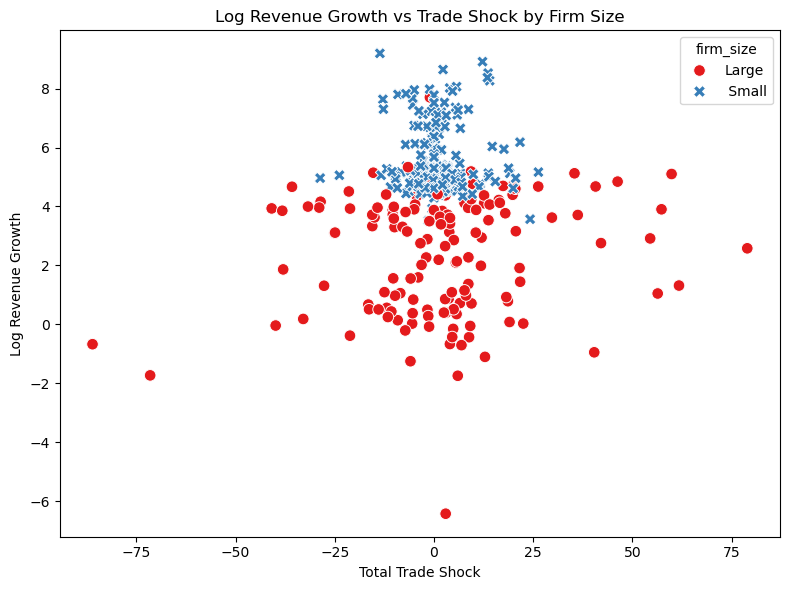

In [36]:
# Collapsing by industry, time and size
collapsed = (
    data
    .groupby(["industry", "Year", "small"], as_index=False)
    .agg({
        "shock2": "mean",    # add other numeric columns as needed
        "growth": "mean",               # if you have growth variable
        "shock": "mean"                 # if you have shock variable
    })
)
collapsed = collapsed.rename(columns={"small": "firm_size"})
# Log Transforming of revenue growth
collapsed['log_growth'] = np.log1p(collapsed['growth'])

plt.figure(figsize=(8,6))
ax=sns.scatterplot(
    data=collapsed,
    x="shock", 
    y="log_growth", 
    hue="firm_size",        # color points by firm size
    style="firm_size",      # optional: different markers by size
    palette="Set1",    # choose a nice color palette
    s=70               # point size
)

new_labels = ["Large", " Small"]
for t, l in zip(ax.legend_.texts, new_labels):
    t.set_text(l)

plt.title("Log Revenue Growth vs Trade Shock by Firm Size")
plt.xlabel("Total Trade Shock")
plt.ylabel("Log Revenue Growth")
#plt.legend(title="Firm Size")
plt.tight_layout()
plt.show()


The scatter plot shows that most firms cluster around zero trade shock, suggesting limited exposure for many. Small firms tend to show higher log revenue growth than large firms with in an industry, especially near zero or positive trade shocks. Small firms appear more resilient to trade shocks, especially near zero or positive values. Large firms show lower log revenue growth. They are more likely to be exposed to very large trade shocks. The relationship between trade shock and growth is not strongly linear. Firm size moderates the effect of trade shocks on revenue growth with smaller firms tends to negate the effects of the largers firms.




In [38]:
# Outlier
# --- Step 1: Calculate IQR for revenue_growth ---
Q1 = data["growth"].quantile(0.25)
Q3 = data["growth"].quantile(0.75)
IQR = Q3 - Q1

# --- Step 2: Define bounds ---
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# --- Step 3: Filter out outliers ---
df_filtered = data[(data["growth"] >= lower_bound) & (data["growth"] <= upper_bound)]

collapsed_f = (
    df_filtered
    .groupby(["industry", "Year", "small"], as_index=False)
    .agg({
        "shock2": "mean",    # add other numeric columns as needed
        "growth": "mean",               # if you have growth variable
        "shock": "mean"                 # if you have shock variable
    })
)

C:\Users\mritt\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


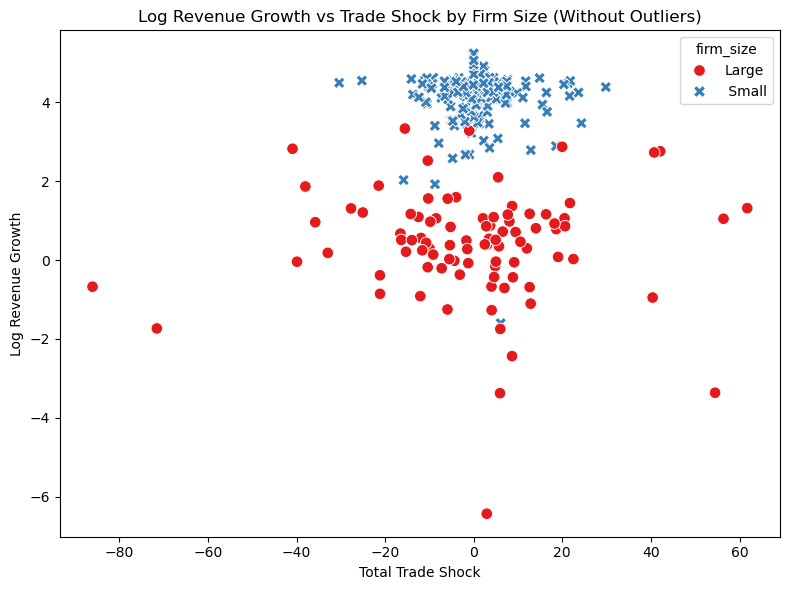

In [39]:
collapsed_f = collapsed_f.rename(columns={"small": "firm_size"})
# Log Transforming of revenue growth
collapsed_f['log_growth'] = np.log1p(collapsed_f['growth'])

plt.figure(figsize=(8,6))
ax=sns.scatterplot(
    data=collapsed_f,
    x="shock", 
    y="log_growth", 
    hue="firm_size",        # color points by firm size
    style="firm_size",      # optional: different markers by size
    palette="Set1",    # choose a nice color palette
    s=70               # point size
)

new_labels = ["Large", " Small"]
for t, l in zip(ax.legend_.texts, new_labels):
    t.set_text(l)

plt.title("Log Revenue Growth vs Trade Shock by Firm Size (Without Outliers)")
plt.xlabel("Total Trade Shock")
plt.ylabel("Log Revenue Growth")
#plt.legend(title="Firm Size") 
plt.tight_layout()
plt.show()

Using cleaned panel data excluding outliers, the scatter plot reveals distinct patterns across firm categories.
Small firms consistently exhibit higher log revenue growth than large firms, particularly in the zone of minimal trade shock exposure. Their growth outcomes are tightly clustered, suggesting resilience and agility in navigating trade fluctuations. In contrast, large firms display a wider dispersion in both trade shock and growth, indicating greater vulnerability or heterogeneity in response strategies. The relationship between trade shocks and revenue growth seems to be not clear.


In [41]:
# Changing all revenue growth to log revenue growth
data['log_growth'] = np.log1p(data['growth'])
df_filtered['log_growth'] = np.log1p(df_filtered['growth'])
# Interaction between trade shock and small
data['trade_small'] = data["shock"]*data["small"]
df_filtered['trade_small'] = df_filtered["shock"]*df_filtered["small"]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51514 entries, 1 to 53892
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NAICS              51514 non-null  int64  
 1   small              51514 non-null  int64  
 2   Year               51514 non-null  int64  
 3   revenue            51514 non-null  float64
 4   industry           51514 non-null  int32  
 5   Value of exports   51514 non-null  float64
 6   Value of imports   51514 non-null  float64
 7   GDP                51514 non-null  float64
 8   total_trade        51514 non-null  float64
 9   trade_pct_gdp      51514 non-null  float64
 10  lag_trade_pct_gdp  51514 non-null  float64
 11  shock              51514 non-null  float64
 12  penetration        51514 non-null  float64
 13  lag_p              51514 non-null  float64
 14  shock2             51514 non-null  float64
 15  prev_revenue       51514 non-null  float64
 16  growth             51514 no

C:\Users\mritt\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\mritt\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\mritt\AppData\Local\Temp\ipykernel_17312\1612388703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['log_growth'] = np.log1p(df_filtered['growth'])
C:\Users\mritt\AppData\Local\Temp\ipykernel_17312\1612388703.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

In [42]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47837 entries, 1 to 53892
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NAICS              47837 non-null  int64  
 1   small              47837 non-null  int64  
 2   Year               47837 non-null  int64  
 3   revenue            47837 non-null  float64
 4   industry           47837 non-null  int32  
 5   Value of exports   47837 non-null  float64
 6   Value of imports   47837 non-null  float64
 7   GDP                47837 non-null  float64
 8   total_trade        47837 non-null  float64
 9   trade_pct_gdp      47837 non-null  float64
 10  lag_trade_pct_gdp  47837 non-null  float64
 11  shock              47837 non-null  float64
 12  penetration        47837 non-null  float64
 13  lag_p              47837 non-null  float64
 14  shock2             47837 non-null  float64
 15  prev_revenue       47837 non-null  float64
 16  growth             47837 no

### Estimation 

In [44]:
data= data.set_index(["NAICS", "Year"]) # Setting data as panel
model = PanelOLS.from_formula(
    "log_growth ~  shock + small + trade_small + EntityEffects +TimeEffects ",
    data=data.dropna()
)
results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             log_growth   R-squared:                        0.4931
Estimator:                   PanelOLS   R-squared (Between):              0.8801
No. Observations:               22460   R-squared (Within):               0.4956
Date:                Fri, Dec 12 2025   R-squared (Overall):              0.7753
Time:                        18:24:24   Log-likelihood                -4.418e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6782.7
Entities:                        1532   P-value                           0.0000
Avg Obs:                       14.661   Distribution:                 F(3,20915)
Min Obs:                       1.0000                                           
Max Obs:                       34.000   F-statistic (robust):             1894.9
                            

In [45]:
df_filtered= df_filtered.set_index(["NAICS", "Year"]) # Setting data as panel
model = PanelOLS.from_formula(
    "log_growth ~  shock + small + trade_small + EntityEffects +TimeEffects ",
    data=df_filtered.dropna()
)
results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             log_growth   R-squared:                        0.6620
Estimator:                   PanelOLS   R-squared (Between):              0.8350
No. Observations:               18783   R-squared (Within):               0.6652
Date:                Fri, Dec 12 2025   R-squared (Overall):              0.7690
Time:                        18:24:24   Log-likelihood                -2.988e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.128e+04
Entities:                        1496   P-value                           0.0000
Avg Obs:                       12.555   Distribution:                 F(3,17274)
Min Obs:                       1.0000                                           
Max Obs:                       31.000   F-statistic (robust):             1376.6
                            

Estimation suggest that higher trade shock is associated with higher log revenue growth, holding other factors constant.The effect size is modest but robust with a p-value of 0%.

Size of firms matters. Coefficient indicates that small firms, on average, have substantially higher log revenue growth compared to large firms. This aligns with your scatter plots showing small firms clustered at higher growth levels.

The interaction term is negative coefficient, marginally significant (just above the 5% threshold, but below 10%), suggesting that the interaction between being small and experiencing trade shock slightly reduces growth relative to the baseline. In other words, while small firms generally grow faster, their advantage diminishes somewhat as trade shocks increase.



In [47]:
## Import Penetration

In [48]:
collapsed.describe()

,industry,Year,firm_size,shock2,growth,shock,log_growth
count,378.000000,378.000000,378.000000,378.000000,378.000000,378.000000,345.000000
mean,47.611111,2018.238095,0.523810,-1.527426,341.675076,1.890826,4.223338
std,19.016803,3.041957,0.500095,24.776416,926.837735,16.572116,2.213439
min,11.000000,2013.000000,0.000000,-259.884554,-29.301780,-86.064837,-6.427290
25%,31.000000,2016.000000,0.000000,-3.718694,7.589814,-4.582681,3.516524
50%,52.000000,2018.000000,1.000000,0.876944,97.469347,0.923519,4.668621
75%,61.000000,2021.000000,1.000000,5.917305,174.953888,6.650842,5.279836
max,81.000000,2023.000000,1.000000,53.502255,9862.945922,78.956115,9.196642


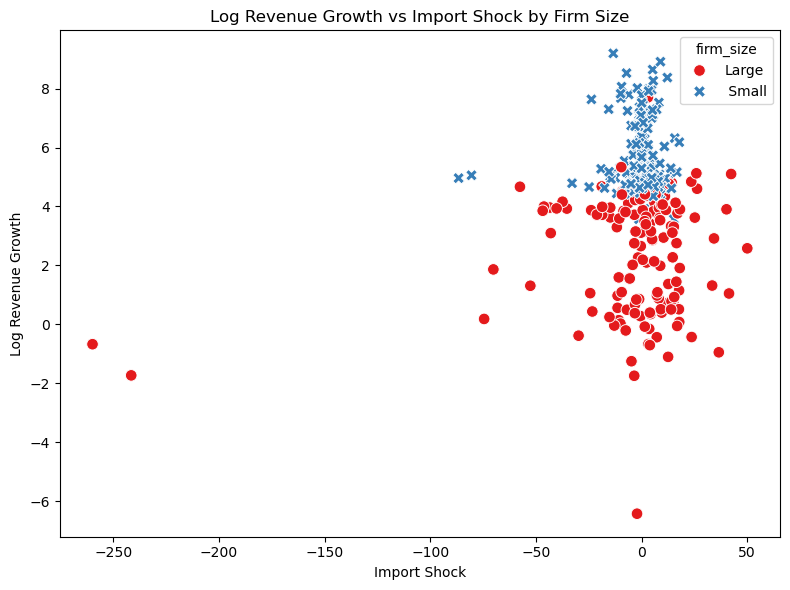

In [49]:

plt.figure(figsize=(8,6))
ax=sns.scatterplot(
    data=collapsed,
    x="shock2", 
    y="log_growth", 
    hue="firm_size",        # color points by firm size
    style="firm_size",      # optional: different markers by size
    palette="Set1",    # choose a nice color palette
    s=70               # point size
)

new_labels = ["Large", " Small"]
for t, l in zip(ax.legend_.texts, new_labels):
    t.set_text(l)

plt.title("Log Revenue Growth vs Import Shock by Firm Size")
plt.xlabel("Import Shock")
plt.ylabel("Log Revenue Growth")
#plt.legend(title="Firm Size")
plt.tight_layout()
plt.show()

- Small firms (blue crosses) cluster more tightly around the center of the import shock axis and they tend to show higher log revenue growth than large firms. They appear less sensitive to variation in import shock, suggesting resilience or limited exposure.
- Large firms (red circlles) display a wider spread in both import shock and revenue growth. Some show negative growth under higher import shocks, indicating vulnerability. The dispersion may suggest some large firms may be more exposed to global competition.


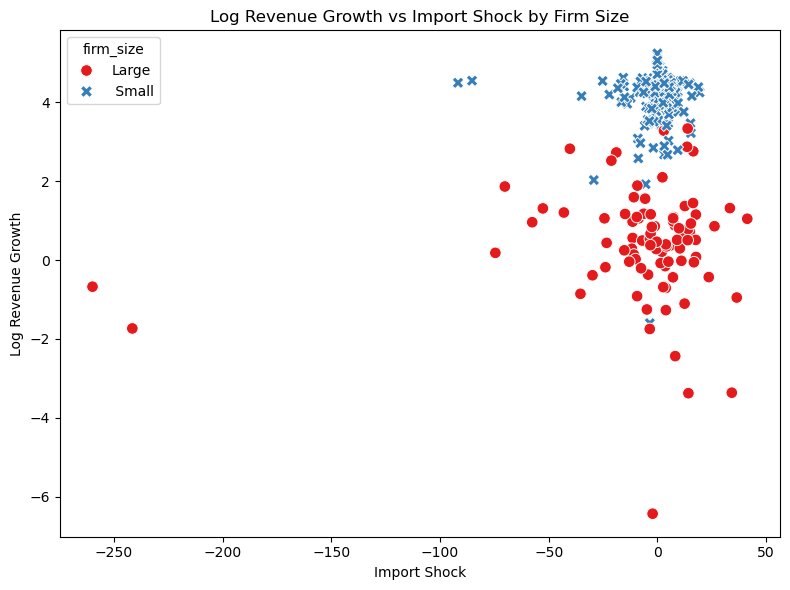

In [51]:
plt.figure(figsize=(8,6))
ax=sns.scatterplot(
    data=collapsed_f,
    x="shock2", 
    y="log_growth", 
    hue="firm_size",        # color points by firm size
    style="firm_size",      # optional: different markers by size
    palette="Set1",    # choose a nice color palette
    s=70               # point size
)

new_labels = ["Large", " Small"]
for t, l in zip(ax.legend_.texts, new_labels):
    t.set_text(l)

plt.title("Log Revenue Growth vs Import Shock by Firm Size")
plt.xlabel("Import Shock")
plt.ylabel("Log Revenue Growth")
#plt.legend(title="Firm Size")
plt.tight_layout()
plt.show()

## Estimations

In [53]:
model = PanelOLS.from_formula(
    "log_growth ~  shock2 + small + trade_small + EntityEffects +TimeEffects ",
    data=data.dropna()
)
results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             log_growth   R-squared:                        0.4925
Estimator:                   PanelOLS   R-squared (Between):              0.8778
No. Observations:               22460   R-squared (Within):               0.4950
Date:                Fri, Dec 12 2025   R-squared (Overall):              0.7736
Time:                        18:24:25   Log-likelihood                -4.419e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6766.6
Entities:                        1532   P-value                           0.0000
Avg Obs:                       14.661   Distribution:                 F(3,20915)
Min Obs:                       1.0000                                           
Max Obs:                       34.000   F-statistic (robust):             1669.9
                            

In [54]:
model = PanelOLS.from_formula(
    "log_growth ~  shock2 + small + trade_small + EntityEffects +TimeEffects ",
    data=df_filtered.dropna()
)
results = model.fit(cov_type="clustered", cluster_entity=True)

print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             log_growth   R-squared:                        0.6620
Estimator:                   PanelOLS   R-squared (Between):              0.8340
No. Observations:               18783   R-squared (Within):               0.6653
Date:                Fri, Dec 12 2025   R-squared (Overall):              0.7685
Time:                        18:24:25   Log-likelihood                -2.988e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.128e+04
Entities:                        1496   P-value                           0.0000
Avg Obs:                       12.555   Distribution:                 F(3,17274)
Min Obs:                       1.0000                                           
Max Obs:                       31.000   F-statistic (robust):             1372.9
                            

Same results as with the total trade shocks.
Conclusion: Small firms enjoy a strong growth premium overall, yet their sensitivity to trade shocks may be slightly negative compared to large firms.